<a href="https://colab.research.google.com/github/ilariatomei2004-gif/esercitazioni/blob/main/Notebook_GNN_v1.0.4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os

repo_name = 'progetto_GraphColouring_ML26'
repo_url = 'https://github.com/gien-7/progetto_GraphColouring_ML26.git' #importa proprio da github

if not os.path.exists(repo_name):
    !git clone {repo_url}
else:
    print(f"La cartella '{repo_name}' è già caricata")

La cartella 'progetto_GraphColouring_ML26' è già caricata


In [3]:
from torch.utils.data import TensorDataset, Dataset, DataLoader
import torch
import torch.utils.data as data

!pip install torch_geometric

In [4]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

In [5]:
seed = 42

#Preprocessing

In [6]:
import pandas as pd

file1 = 'progetto_GraphColouring_ML26/g6.col'  # queen9x9
file2 = 'progetto_GraphColouring_ML26/g17.col'  # miles750

df_g6 = pd.read_csv(file1, sep='\s+', skiprows=4, usecols=[1,2], names=['node1','node2'])
df_g17 = pd.read_csv(file2, sep='\s+', skiprows=4, usecols=[1,2], names=['node1','node2'])

print('Shape g6.col  : ',df_g6.shape)
print('Shape g17.col : ',df_g17.shape)

Shape g6.col  :  (2112, 2)
Shape g17.col :  (4226, 2)


##queen9x9

In [7]:
print(df_g6) #ogni donna puo interagire con le caselle che ha intorno (al bordo ha meno caselle)
#node 1 ti da la casella di partenza, node 2 quelle a cui è collegata
#il filw contiene quindi tutti gli edges

      node1  node2
0         1     11
1         1     21
2         1     31
3         1     41
4         1     51
...     ...    ...
2107     81     21
2108     81     18
2109     81     11
2110     81      9
2111     81      1

[2112 rows x 2 columns]


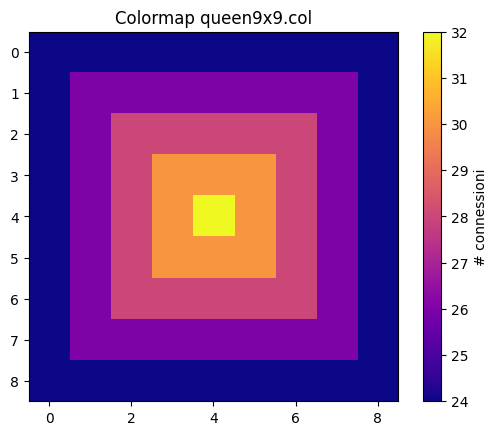

In [8]:
import numpy as np
import matplotlib.pyplot as plt
#meno sei al centro meno connesioni hai
unique, counts = np.unique(df_g6['node1'].values, return_counts=True)  # non cambierebbe nulla se operassi invece su node2 per simmetria
# unique prende una volta sola gli elementi, values trasforma in array
queen_intensity = counts.reshape(9,9) #trasformo l'arary in griglia

plt.imshow(queen_intensity, cmap='plasma')
plt.colorbar(label = '# connessioni')
plt.title('Colormap queen9x9.col')
plt.show()

In [9]:
index_grid = (unique-1).reshape(9,9) #indice di ogni nodo, scacchiera
index_grid

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8],
       [ 9, 10, 11, 12, 13, 14, 15, 16, 17],
       [18, 19, 20, 21, 22, 23, 24, 25, 26],
       [27, 28, 29, 30, 31, 32, 33, 34, 35],
       [36, 37, 38, 39, 40, 41, 42, 43, 44],
       [45, 46, 47, 48, 49, 50, 51, 52, 53],
       [54, 55, 56, 57, 58, 59, 60, 61, 62],
       [63, 64, 65, 66, 67, 68, 69, 70, 71],
       [72, 73, 74, 75, 76, 77, 78, 79, 80]])

**Data augmentation sfruttando invarianze per simmetria del problema**

In [10]:

def build_edges_from_df(col1, col2):
  src = torch.tensor(col1.values, dtype=torch.long) #nodo 1, formato long perchè va cosi
  dst = torch.tensor(col2.values, dtype=torch.long)
  edge_index = torch.stack([src, dst], dim=0)
  return edge_index

#data aigmentation qui non avrebbe molto senso ma può essere utile per evitare di memorizzare soluzioni sbagliata (DA VALUTARE)
def transform_node_index(x, y, k_rot, do_flip=False): #combinazione di rotazione e riflessione (8)
    if do_flip:
        x=-x
    for _ in range(k_rot):
        # Rotazione 90°: (x, y) -> (y, -x)
        x, y = y, -x
    pos_n_aug = torch.stack([x, y], dim=1) #gia in tensore
    return pos_n_aug

def transform_edges(serie, k_rot, do_flip=False): #cambia la mappa degli edges in funzione della rotazione dei nodi (ATTENZIONE POSSIBILI ERRORI)
  idx = serie-1  # da 1->81 a 0->80
  r = idx // 9
  c = idx % 9
  if do_flip:
    c = 8 - c
  for _ in range(k_rot):
    r, c = c, 8 - r
  return (r * 9 + c) +1 #da 0->80 a 1->81

In [11]:
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data

class QueenGraphGenerator(Dataset):  # Cambiamento rispetto alla CNN: il Dataset ora produce grafi PyG, non immagini.
    def __init__(self, X, df, AUGMENT=True):
      super().__init__()
      self.X = X  # intenità nodi
      self.df = df
      self.AUGMENT = AUGMENT

    def __len__(self):  # Ritorna la dimensione del dataset
      return len(self.X)

    def __getitem__(self, idx): #ritorna l'elemento idx del dataset
      intensity = self.X[idx].copy()
      node_list = self.df[idx].copy() # copy() per evitare che augment modifichi i dati originali
      col1_label = (self.df[idx].columns)[0]
      col2_label = (self.df[idx].columns)[1]

      k_rot = 0
      do_flip = False

      rows, cols = np.indices((9, 9)) #ripete numeri in colonne e righe
      rows = rows.reshape(-1) # [0,0,0...1,1,1...n,n,n]
      cols = cols.reshape(-1) # [0,1,2...,0,1,2,...]
      values = intensity[rows, cols].astype(np.float32)  # sarà unidimensionale avendo flattenato, è strano ma vabe, deve essere float32

      # data.pos contiene le coordinate geometriche non normalizzate delle connessioni sul piano 9x9.
      pos = torch.tensor(np.stack([rows, cols], axis=1), dtype=torch.float) # su asse 1 è sulle colonne, 81x2, coordinate possibili
      pos_n = (pos/8.) * 2. - 1.  #normalizza da -1 a 1

      '''
      L'augmentation ha il fine di cambiare l'ordine degli indici
      quindi magari [0][2]=(2) -> [8][6]=(79)'. Segue che, oltre a ruotare
      il tensore delle posizioni, dovrò anche cambiare i vari edges:
      la nuova posizione (79)' eredita le connessioni di (2), e viceversa per (2)'.
      D'altro canto, la feature d'intensity non varia per simmetria del problema!
      Per formalismo è stato fatto lo stesso.
      '''

      if self.AUGMENT: # solo in training!!
        k_rot = np.random.randint(0, 4)
        do_flip = np.random.choice([True, False])
        x_coords = pos_n[:, 0].clone()
        y_coords = pos_n[:, 1].clone()
        pos_n = transform_node_index(x_coords, y_coords, k_rot, do_flip)

        node_list[col1_label] = transform_edges(node_list[col1_label].values, k_rot, do_flip)
        node_list[col2_label] = transform_edges(node_list[col2_label].values, k_rot, do_flip)

      # Creo vettore x contenente
      value = torch.tensor(values/values.sum(), dtype=torch.float).view(-1, 1) #trasforma l'array delle intensità in 2d con la famosa dim dummy.
      x = torch.cat([value, pos_n], dim=1)  # torch vuole dimensione dummy delle label di x, ritorna coppie

      # L'output di build_knn_edges del tipo torch.Tensor(2, (num_nodes x k_eff)), interi int64
      edge_index = build_edges_from_df(node_list[col1_label]-1, node_list[col2_label]-1)
      # In input le due serie relative al dataframe, scalate di 1 (anzichè fare da 1->9 fa 0->8)

      # Problema unsupervised, uso y dummy pari a indici delle caselle
      tensor_label = torch.arange(81, dtype=torch.long) #non è niente perche y prende i valori veri che in questo caso non ci sono. (possibile errore)

      return Data(x=x, edge_index=edge_index, y=tensor_label, pos=pos_n) #x è coordinata con intensità

In [12]:
#se sei confuso con le shape prova qui, non runna...
'''rows = rows.reshape(-1)
cols = cols.reshape(-1)
print(np.stack([rows, cols], axis=0)) #dim 0 numero di array
print(np.stack([rows, cols], axis=1)) #dim 1 righe degli array, dim 2 colonne'''

'rows = rows.reshape(-1)\ncols = cols.reshape(-1)\nprint(np.stack([rows, cols], axis=0)) #dim 0 numero di array\nprint(np.stack([rows, cols], axis=1)) #dim 1 righe degli array, dim 2 colonne'

In [13]:
queen_df = df_g6.copy()
N = 32  # randomizzerò 32 volte per epoca, sullo stesso grafo di partenza
multi_X = [queen_intensity] * N
multi_df = [queen_df] * N

queen_dataset = QueenGraphGenerator(multi_X, multi_df, AUGMENT=True) #chiedi per sicurezza
queen_loader = DataLoader(queen_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True, drop_last=True) #eventualmente batch_size=2

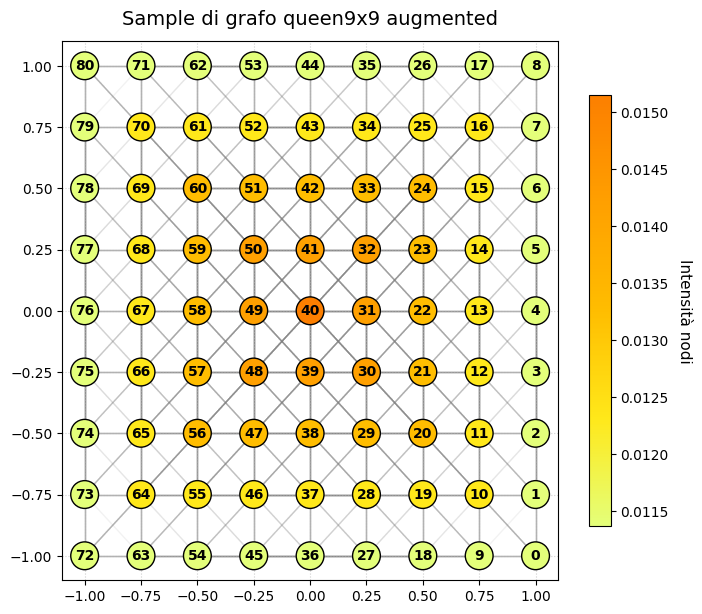

In [14]:
from torch_geometric.utils import to_networkx
import networkx as nx

data = queen_dataset[0]
G = to_networkx(data, to_undirected=True)
pos_dict = {i: data.pos[i].numpy() for i in range(data.num_nodes)}

fig, ax = plt.subplots(figsize=(8, 7))

nodes = nx.draw_networkx_nodes(G, pos_dict,
                               ax=ax,
                               node_size=400,
                               node_color=data.x[:, 0].numpy(),
                               cmap='Wistia',
                               edgecolors='black')

nx.draw_networkx_edges(G, pos_dict, ax=ax, alpha=0.1, edge_color='gray')
nx.draw_networkx_labels(G, pos_dict, ax=ax,
                        font_size=10,
                        font_family='sans-serif',
                        font_weight='bold')

cbar = fig.colorbar(nodes, shrink = 0.8, ax=ax)
cbar.set_label('Intensità nodi', rotation=270, labelpad=17, fontsize=11)

ax.set_axis_on()
ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)

x_coords = data.pos[:, 0].numpy()
y_coords = data.pos[:, 1].numpy()
ax.set_xlim(x_coords.min() - 0.1, x_coords.max() + 0.1)
ax.set_ylim(y_coords.min() - 0.1, y_coords.max() + 0.1)

ax.grid(True, linestyle=':', alpha=0.6)
ax.set_title("Sample di grafo queen9x9 augmented", fontsize=14, pad=12)

plt.show()

In [15]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print('Using',device, 'device')

Using cuda device


MODELLO GNN

In [51]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, global_mean_pool

'''#nella rete usiamo SAGEConv e poi Linear. all'ultimo va usato softmax perchè non usiamo cross entropy come loss.
# 2-3 layer per grafi con meno di 100 nodi altrimenti si fa oversmoothing (nodi tutti simili). Infatti è un problema locale, basta guardare i vicini.
class GNN_net(nn.Module):
    def __init__(self, c, i_dim=3):
        super().__init__()

        # embedding learnable dei nodi
        #self.emb = nn.Embedding(n_nodes, i_dim)

        # message passing
        self.conv1 = SAGEConv(i_dim, 32)
        self.conv2 = SAGEConv(32, 64)
        self.conv3 = SAGEConv(64, 64)

        # output logits colori
        self.fc = nn.Linear(64, c)

    def forward(self, data):

        #device = edge_index.device
        x, edge_index, batch = data.x, data.edge_index, data.batch

        #n_nodes = self.emb.num_embeddings


      # node_ids = torch.arange(
       #     n_nodes,
            #device=device
        #)


        # embedding iniziali
       # x = self.emb(node_ids)

        # message passing
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))

        # logits colori
        logits = self.fc(x)

        # distribuzione soft sui colori
        p = F.softmax(logits, dim=-1)

        return p


model = GNN_net(c=5)'''

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import SAGEConv

class PottsSAGENet(nn.Module):

    def __init__(self, in_channels=3, hidden_dim=64, num_colors=4):
        super().__init__()

        self.conv1 = SAGEConv(in_channels, 32)
        self.conv2 = SAGEConv(32, 64)
        self.conv3 = SAGEConv(64, hidden_dim)

        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)

        self.dropout = nn.Dropout(0.)

        # output: logits dei colori
        self.fc3 = nn.Linear(hidden_dim, num_colors)

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index

        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))

        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = F.relu(self.fc2(x))
        x = self.dropout(x)

        logits = self.fc3(x)

        return logits
model = PottsSAGENet()

In [52]:
model.to(device)
print(model)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Numero di parametri trainabili:", num_params)



PottsSAGENet(
  (conv1): SAGEConv(3, 32, aggr=mean)
  (conv2): SAGEConv(32, 64, aggr=mean)
  (conv3): SAGEConv(64, 64, aggr=mean)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc3): Linear(in_features=64, out_features=4, bias=True)
)
Numero di parametri trainabili: 21220


In [64]:
batch = next(iter(queen_loader))
batch = batch.to(device)

logits = model(batch)

print(logits.shape)

torch.Size([324, 4])


In [65]:
def potts_loss(probs, edge_index):
    """
    probs: [num_nodes, num_colors] - soft color assignments
    edge_index: [2, num_edges] - grafo
    """
    src, dst = edge_index

    # Prodotto scalare per ogni arco
    overlap = (probs[src] * probs[dst]).sum(dim=-1)  # [num_edges]

    return overlap.sum()


In [66]:
model = PottsSAGENet(
    in_channels=3,
    hidden_dim=64,
    num_colors=4
).to(device)



In [67]:
def train_graph_coloring(edge_index, num_nodes, num_colors,
                          hidden_dim=64, epochs=1000, lr=0.01):

    model = PottsSAGENet(num_nodes, hidden_dim, num_colors)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Forward: ottieni soft assignment
        probs = model(edge_index)

        # Loss principale: energia di Potts
        loss = potts_loss(probs, edge_index)

        # (Opzionale) Entropy regularization per spingere verso assegnamenti netti
        entropy = -(probs * torch.log(probs + 1e-8)).sum()
        loss = loss - 0.01 * entropy  # minimizza overlap, massimizza certezza

        loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            # Valuta colorazione discreta
            colors = probs.argmax(dim=-1)
            conflicts = count_conflicts(colors, edge_index)
            print(f"Epoch {epoch}: Loss={loss.item():.4f}, Conflicts={conflicts}")

    # Estrai colorazione finale
    final_probs = model(edge_index)
    final_colors = final_probs.argmax(dim=-1)

    return final_colors, model


def count_conflicts(colors, edge_index):
    src, dst = edge_index
    return (colors[src] == colors[dst]).sum().item()


In [68]:
print(train_graph_coloring(edge_index = batch.edge_index, num_nodes=81, num_colors =4,
                          hidden_dim=64, epochs=1000, lr=0.01))

AttributeError: 'Tensor' object has no attribute 'x'

In [ ]:
model.eval()

with torch.no_grad():
    logits = model(batch)

with torch.no_grad():

    p = F.softmax(logits, dim=1)

    print(p[:5])
print(logits)
colors = logits.argmax(dim=1)
print(colors)

In [ ]:
colors = np.argmax(prob.detach().cpu().numpy(), axis=1)
print(colors)

In [ ]:
batch = next(iter(queen_loader))
print(batch.edge_index)
rows, cols = batch.edge_index
#print(len(rows))
print(cols)
#batch.x.shape
#print(queen_dataset[0])

##miles750

In [ ]:
print(df_g17) #connessione vuol dire vicine entro 750 miglia

In [ ]:
unique, counts = np.unique(df_g17['node1'].values, return_counts=True)  # non cambierebbe nulla se operassi invece su node2 per simmetria
miles_intensity = counts.astype(np.float32)

In [ ]:
G = nx.Graph()
G.add_edges_from(zip(df_g17['node1'], df_g17['node2']))

pos = nx.spring_layout(G, seed=seed) #stampa mantenendo le distanze con posizioni casuali

In [ ]:
import collections

od = collections.OrderedDict(sorted(pos.items()))  #ordina dizionario dalle keys
od_keys = []
od_vals = []
for k, v in od.items():
  od_keys.append(k)
  od_vals.append(v)

od_vals = np.array(od_vals) #dizionario con posizioni farlocche di tutti i nodi (x,y)
#print(od_vals)
#od_keys è in struttura uguale a unique

In [ ]:
class MilesGraphGenerator(Dataset):
    def __init__(self, X, df, coords, AUGMENT=True):
        self.X = X
        self.df = df
        self.coords = coords
        self.AUGMENT = AUGMENT

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        intensity = self.X.copy()
        node_list = self.df.copy()
        coords_sim = self.coords.copy()
        col1_label = (self.df.columns)[0]
        col2_label = (self.df.columns)[1]

        edge_index_raw = build_edges_from_df(node_list[col1_label]-1, node_list[col2_label]-1)
        num_nodes = len(intensity)

        '''
        Augmentation con stessa filosofia di queen9x9, ma adesso non voglio ruotare
        secondo il gruppo di simmetria: essendo i nodi liberi, ovvero non dipendenti
        dalle posizioni ma dalle connessioni, mi concentro sul generalizzare il grafo
        permutando, con l'obiettivo di non incorrere in minimi come prima.
        '''

        if self.AUGMENT:
            perm = torch.randperm(num_nodes)  # rimescolamento degli indici
            intensity = intensity[perm]
            coords_sim = coords_sim[perm]
            #Rimappo gli archi affinché puntino ai nuovi indici
            reverse_perm = torch.empty_like(perm)
            reverse_perm[perm] = torch.arange(num_nodes)
            edge_index = reverse_perm[edge_index_raw]
        else:
            edge_index = edge_index_raw

        pos = torch.tensor(coords_sim, dtype=torch.float)
        p_min, p_max = pos.min(), pos.max()
        pos_n = ((pos - p_min) / (p_max - p_min + 1e-7)) * 2. - 1.

        val_t = torch.tensor(intensity / (intensity.sum() + 1e-7), dtype=torch.float).view(-1, 1)

        x = torch.cat([val_t, pos_n], dim=1)

        tensor_label = torch.arange(128, dtype=torch.long)

        return Data(x=x, edge_index=edge_index, y=tensor_label, pos=pos_n)

In [ ]:
# N e batches da definire nell'allenamento
miles_df = df_g17.copy()
N = 32  # randomizzerò 800 volte per epoca, sullo stesso grafo di partenza
multi_X = [miles_intensity] * N
multi_df = [miles_df] * N
multi_od_vals = [od_vals] * N

miles_dataset = MilesGraphGenerator(miles_intensity, miles_df, od_vals, AUGMENT=True)
miles_loader = DataLoader(miles_dataset, batch_size=4, shuffle=True)

In [ ]:
data = miles_dataset[0]
G = to_networkx(data, to_undirected=True)
pos_dict = {i: data.pos[i].numpy() for i in range(128)}

fig, ax = plt.subplots(figsize=(8, 7))

nodes = nx.draw_networkx_nodes(
    G, pos_dict,
    ax=ax,
    node_size=150,
    node_color=data.x[:, 0].numpy(),
    cmap='Wistia',
    alpha=0.8
)

nx.draw_networkx_edges(G, pos_dict, ax=ax, alpha=0.5, edge_color="gray")
nx.draw_networkx_labels(G, pos_dict, ax=ax, font_size=8, font_weight='bold')

cbar = fig.colorbar(nodes, shrink = 0.8, ax=ax)
cbar.set_label('Intensità nodi', rotation=270, labelpad=17, fontsize=11)

x_coords = data.pos[:, 0].numpy()
ax.set_xlim(x_coords.min() - 0.1, x_coords.max() + 0.1)
ax.grid(True, linestyle=':', alpha=1.0)

ax.set_title("Sample di grafo miles750 augmented", fontsize=14, pad=12)
ax.set_xlabel("Coordinata X", fontsize=10)
ax.set_ylabel("Coordinata Y", fontsize=10)

plt.show()

In [ ]:
#N.B.: da configurare cuda
#N.B. 2: lo splitting non serve siccome non devo generalizzare